# Day 9 — SHAP Explainability
**Real Estate Fraud Detection**

Goal: Explain model predictions using SHAP — which features drive fraud detection.

**Visualizations:**
| Plot | Purpose |
|------|---------|
| Summary (beeswarm) | Top 20 features — global importance |
| Bar plot | Clean ranking — portfolio main plot |
| Waterfall (×3) | 3 specific fraud cases — feature breakdown |
| Dependence plot | price_per_sqft SHAP vs actual value |
| Force comparison | Fraud vs Normal — push/pull visualization |

**Interview point:** Production mein sirf `is_fraud=True` bolna kaafi nahi. Investigator ko exact signal pata hona chahiye — SHAP deta hai.

**Prerequisites:** Day 8 completed → `models/calibrated_model.pkl` exists

## 0. Set Project Root

In [2]:
import os
from pathlib import Path

project_root = Path.cwd()
while not (project_root / 'configs').exists():
    project_root = project_root.parent
os.chdir(project_root)
print(f'Working directory: {os.getcwd()}')

Working directory: C:\Users\mehal\Downloads\machinelearning\real_estate_fraud_detection


## 1. Imports & Config

In [3]:
import os, sys, warnings
sys.path.insert(0, os.path.abspath('.'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from pathlib import Path

from src.ingestion import load_config
from src.models import load_model
from src.preprocessing import get_feature_names
from src.shap_analysis import (
    compute_shap_values,
    get_feature_importance_df,
    plot_summary,
    plot_bar_importance,
    plot_waterfall,
    plot_dependence,
    plot_force_comparison,
    write_business_insights,
)

CONFIG_PATH = 'configs/config.yaml'
PLOTS_DIR   = 'reports/plots'
cfg = load_config(CONFIG_PATH)
Path(PLOTS_DIR).mkdir(parents=True, exist_ok=True)

print(f'Config: {cfg["project"]["name"]} v{cfg["project"]["version"]}')

# Check shap installed
try:
    import shap
    print(f'SHAP version: {shap.__version__}')
except ImportError:
    print('Installing shap...')
    os.system('pip install shap -q')
    import shap
    print(f'SHAP version: {shap.__version__}')

2026-05-18 10:16:41,814 - src.ingestion - INFO - Config loaded from configs\config.yaml — project: real_estate_fraud_detection v1.1.0


Config: real_estate_fraud_detection v1.1.0
SHAP version: 0.51.0


## 2. Load Model + Data

> SHAP needs the **base LightGBM model** — not the stacked/calibrated wrapper.
> TreeExplainer works directly with LightGBM tree structure.

In [4]:
# Load splits
splits_path = Path(cfg['data']['splits_path'])
X_train = pd.read_parquet(splits_path / 'X_train.parquet')
y_train = pd.read_parquet(splits_path / 'y_train.parquet').squeeze()

print(f'X_train: {X_train.shape} | fraud: {y_train.mean()*100:.2f}%')

# Load tuned results — contains the fitted LightGBM model info
tuned_path = Path(cfg['data']['processed_path']) / 'tuned_results.pkl'
if not tuned_path.exists():
    raise FileNotFoundError('data/processed/tuned_results.pkl not found — run Day 7 first!')

with open(tuned_path, 'rb') as f:
    tuned_data = pickle.load(f)

best_params = tuned_data['best_params']
print(f'Best params loaded: n_estimators={best_params["n_estimators"]}, lr={best_params["learning_rate"]:.4f}')

X_train: (240000, 24) | fraud: 7.82%
Best params loaded: n_estimators=306, lr=0.0754


## 3. Train Final LightGBM for SHAP

> We need a fitted LightGBM model on processed features.
> Train on full X_train with best params — this is the model SHAP will explain.

In [5]:
import lightgbm as lgb
import pickle
from src.features import FeatureEngineer
from src.preprocessing import build_preprocessor, get_feature_names

# Feature engineering
feat_eng = FeatureEngineer(cfg)
feat_eng.fit(X_train, y=y_train)
X_fe = feat_eng.transform(X_train)
X_fe = FeatureEngineer.add_stateless_features(X_fe, cfg)

# Preprocessing — fit on full train
preprocessor = build_preprocessor(cfg, include_city_fraud_rate=True)
preprocessor.fit(X_fe)
X_proc = preprocessor.transform(X_fe)

feature_names = get_feature_names(cfg, include_city_fraud_rate=True)
X_processed = pd.DataFrame(X_proc, columns=feature_names)

print(f'Processed shape: {X_processed.shape}')
print(f'Features: {feature_names}')

2026-05-18 10:16:59,401 - src.features - INFO - FeatureEngineer.fit() — computing fold-dependent stats
2026-05-18 10:17:00,141 - src.features - INFO -   Cities: 1774 | States: 54 | Zip codes: 22307
2026-05-18 10:17:00,400 - src.features - INFO - Fold-dependent features added — 24 total cols
2026-05-18 10:17:00,788 - src.features - INFO - Stateless features added — 9 new columns
2026-05-18 10:17:00,808 - src.preprocessing - INFO - Preprocessor built — 19 numerical, 2 categorical


Processed shape: (240000, 21)
Features: ['price', 'bed', 'bath', 'acre_lot', 'house_size', 'price_per_sqft', 'bath_per_bed', 'price_log', 'house_size_log', 'acre_lot_log', 'is_large_property', 'days_since_last_sale', 'sold_year', 'sold_month', 'price_vs_city_median', 'zip_listing_count', 'city_median_price', 'state_median_price', 'city_fraud_rate', 'status', 'state']


In [6]:
# Train LightGBM with best params
params = {k: v for k, v in best_params.items() if k != 'scale_pos_weight'}
lgbm_model = lgb.LGBMClassifier(
    scale_pos_weight=best_params.get('scale_pos_weight', 1.0),
    **params,
)
lgbm_model.fit(X_processed, y_train)

# Save for inference pipeline
lgbm_path = Path(cfg['paths']['lgbm_model'])
lgbm_path.parent.mkdir(parents=True, exist_ok=True)
with open(lgbm_path, 'wb') as f:
    pickle.dump(lgbm_model, f)

print(f'✅ LightGBM trained on {len(X_processed):,} rows')
print(f'✅ Saved → {lgbm_path}')

✅ LightGBM trained on 240,000 rows
✅ Saved → models\lgbm_model.pkl


## 4. Compute SHAP Values

> TreeExplainer — exact, fast for LightGBM. Samples 2000 rows for speed.

In [7]:
print('Computing SHAP values (sample=2000)...')
shap_values, X_sample = compute_shap_values(
    model=lgbm_model,
    X=X_processed,
    cfg=cfg,
    sample_n=2000,
)

# Align y to same sample
y_sample = y_train.iloc[X_sample.index].reset_index(drop=True)
X_sample = X_sample.reset_index(drop=True)

print(f'SHAP values shape : {shap_values.shape}')
print(f'Sample fraud rate : {y_sample.mean()*100:.2f}%')
print(f'Sample fraud count: {y_sample.sum():,}')

2026-05-18 10:17:09,130 - src.shap_analysis - INFO - Computing SHAP values — 2,000 samples


Computing SHAP values (sample=2000)...


2026-05-18 10:17:11,067 - src.shap_analysis - INFO - SHAP values shape: (2000, 21)


SHAP values shape : (2000, 21)
Sample fraud rate : 7.75%
Sample fraud count: 155


## 5. Feature Importance Table

In [8]:
importance_df = get_feature_importance_df(shap_values, X_sample)

print('Top 10 Features by Mean |SHAP|:')
print(importance_df.head(10)[['rank','feature','mean_shap']].to_string(index=False))

top5 = importance_df.head(5)['feature'].tolist()
print(f'\nTop 5 fraud signals: {top5}')

Top 10 Features by Mean |SHAP|:
 rank              feature  mean_shap
    1 price_vs_city_median   1.315612
    2      city_fraud_rate   0.681205
    3       price_per_sqft   0.662332
    4         bath_per_bed   0.426372
    5                price   0.361363
    6   state_median_price   0.283084
    7    city_median_price   0.280212
    8            price_log   0.182282
    9    zip_listing_count   0.182058
   10           house_size   0.115591

Top 5 fraud signals: ['price_vs_city_median', 'city_fraud_rate', 'price_per_sqft', 'bath_per_bed', 'price']


## 6. Summary Plot (Beeswarm)

> Each dot = one listing. X axis = SHAP value (impact on fraud score).
> Color: red = high feature value, blue = low.

2026-05-18 10:17:15,944 - src.shap_analysis - INFO - Summary plot saved → reports/plots/shap_summary_beeswarm.png


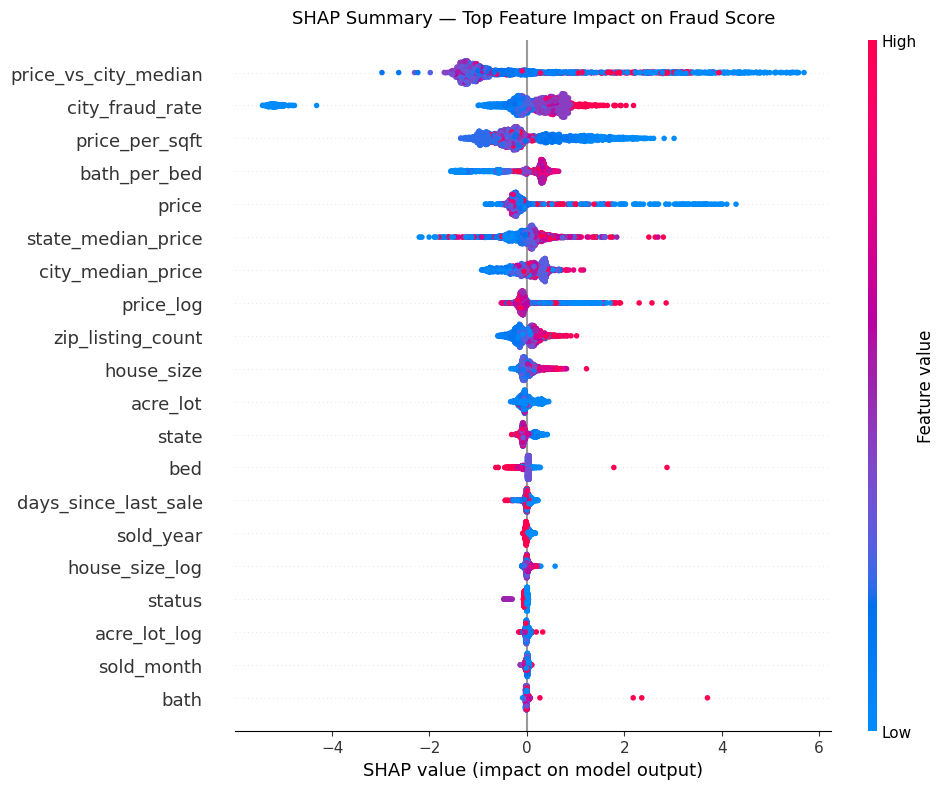

In [9]:
plot_summary(
    shap_values, X_sample,
    plots_dir=PLOTS_DIR,
    max_display=20,
    show=True,
)

## 7. Bar Plot — Feature Importance

> Portfolio main plot — clean, presentable, interview-ready.

2026-05-18 10:17:19,438 - src.shap_analysis - INFO - Bar plot saved → reports/plots/shap_bar_importance.png


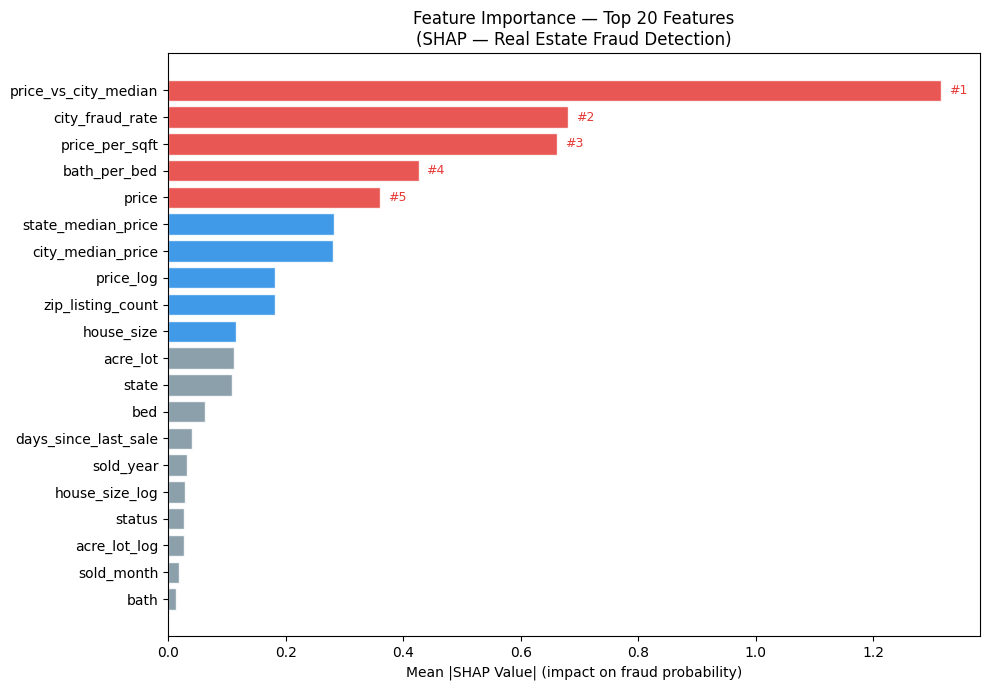


Top feature: price_vs_city_median (mean |SHAP| = 1.3156)


In [10]:
importance_df = plot_bar_importance(
    shap_values, X_sample,
    plots_dir=PLOTS_DIR,
    max_display=20,
    show=True,
)
print(f'\nTop feature: {importance_df.iloc[0]["feature"]} (mean |SHAP| = {importance_df.iloc[0]["mean_shap"]:.4f})')

## 8. Waterfall Plots — 3 Specific Fraud Cases

> Each plot shows exactly which features pushed THIS listing's fraud score.
> Red bars = pushed score UP (fraud signal). Blue = pulled score DOWN.

2026-05-18 10:17:22,985 - src.shap_analysis - INFO - Waterfall plot 1 saved → reports/plots/shap_waterfall_fraud_1.png


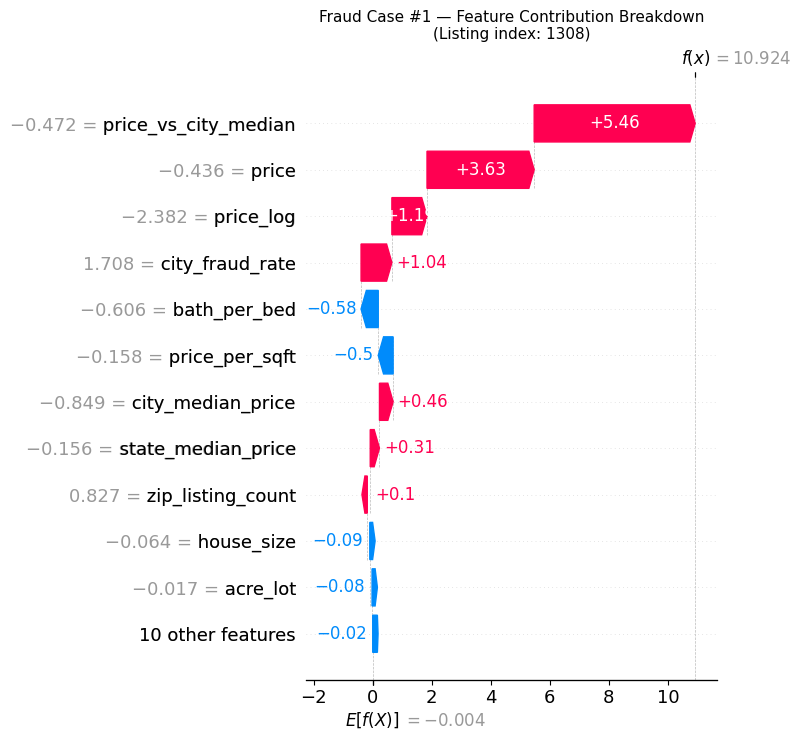

2026-05-18 10:17:26,385 - src.shap_analysis - INFO - Waterfall plot 2 saved → reports/plots/shap_waterfall_fraud_2.png


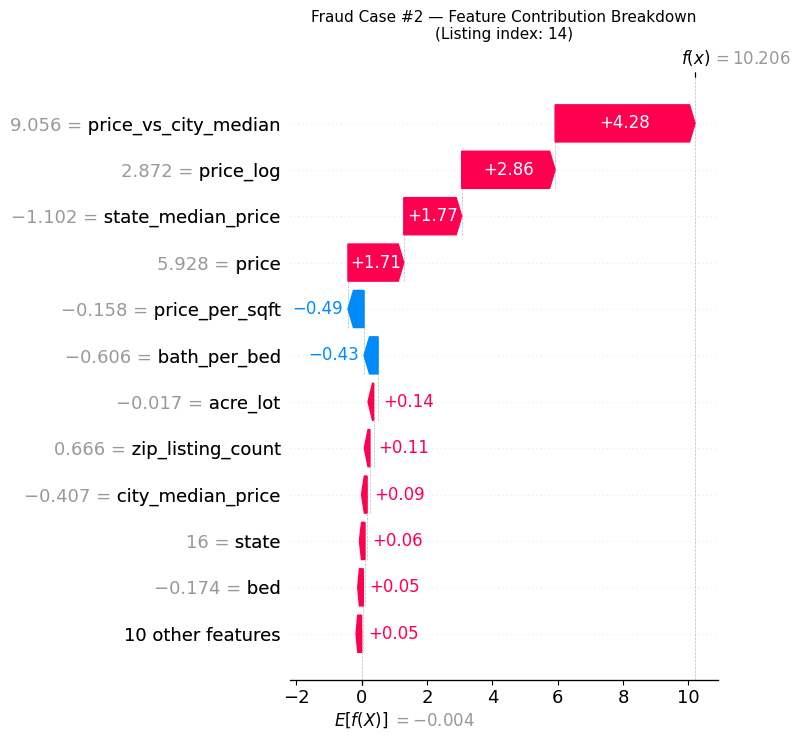

2026-05-18 10:17:29,775 - src.shap_analysis - INFO - Waterfall plot 3 saved → reports/plots/shap_waterfall_fraud_3.png


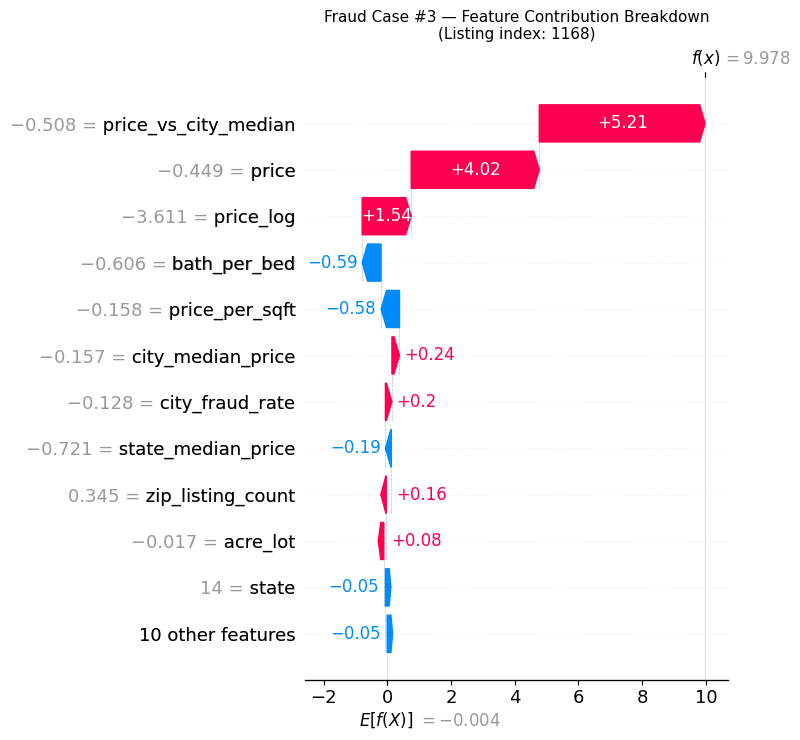

Waterfall plots generated for cases: [1308, 14, 1168]

Fraud listing details (top 3 cases):

Case 1 (index 1308):
  price                    : -0.4362
  price_per_sqft           : -0.1584
  price_vs_city_median     : -0.4719
  house_size               : -0.0643
  acre_lot                 : -0.0168

Case 2 (index 14):
  price                    : 5.9278
  price_per_sqft           : -0.1584
  price_vs_city_median     : 9.0565
  house_size               : -0.0643
  acre_lot                 : -0.0172

Case 3 (index 1168):
  price                    : -0.4490
  price_per_sqft           : -0.1584
  price_vs_city_median     : -0.5081
  house_size               : -0.0643
  acre_lot                 : -0.0174


In [11]:
selected_cases = plot_waterfall(
    model=lgbm_model,
    X_sample=X_sample,
    shap_values=shap_values,
    y_sample=y_sample,
    plots_dir=PLOTS_DIR,
    n_cases=3,
    show=True,
)

print(f'Waterfall plots generated for cases: {selected_cases}')
print('\nFraud listing details (top 3 cases):')
for i, idx in enumerate(selected_cases):
    row = X_sample.iloc[idx]
    print(f'\nCase {i+1} (index {idx}):')
    for feat in ['price', 'price_per_sqft', 'price_vs_city_median', 'house_size', 'acre_lot']:
        if feat in row.index:
            print(f'  {feat:<25}: {row[feat]:.4f}')

## 9. Dependence Plot — price_per_sqft

2026-05-18 10:17:32,134 - src.shap_analysis - INFO - Dependence plot saved → reports/plots/shap_dependence_price_per_sqft.png


<Figure size 1000x600 with 0 Axes>

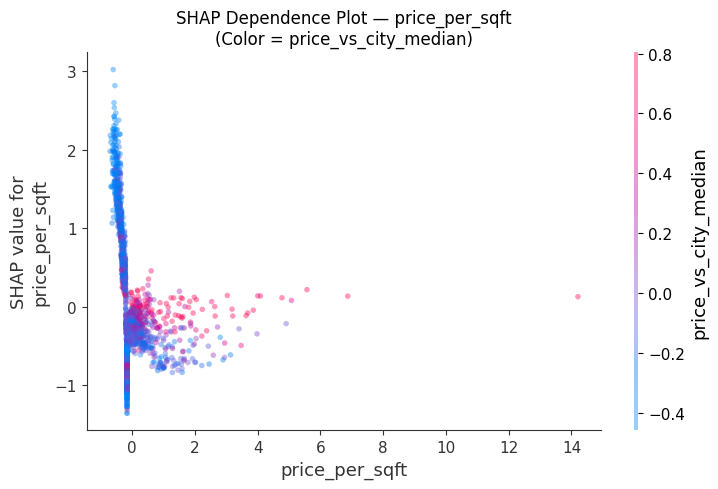

2026-05-18 10:17:34,345 - src.shap_analysis - INFO - Dependence plot saved → reports/plots/shap_dependence_price_vs_city_median.png


<Figure size 1000x600 with 0 Axes>

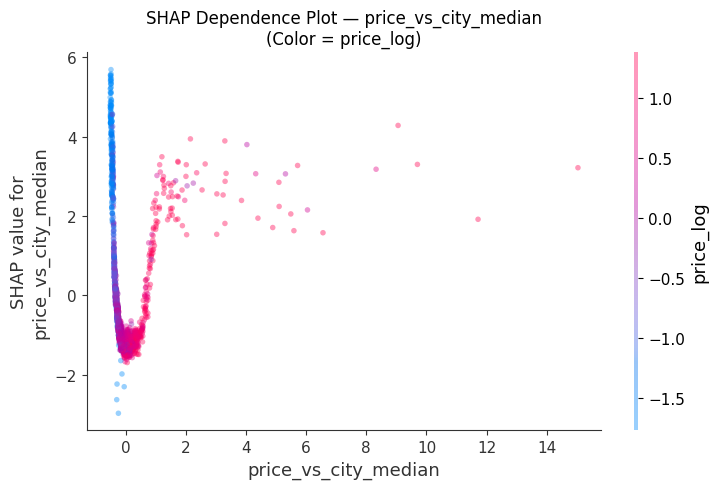

In [12]:
# price_per_sqft — key fraud signal from EDA
plot_dependence(
    shap_values, X_sample,
    feature='price_per_sqft',
    interaction_feature='price_vs_city_median',
    plots_dir=PLOTS_DIR,
    show=True,
)

# Also plot price_vs_city_median
plot_dependence(
    shap_values, X_sample,
    feature='price_vs_city_median',
    interaction_feature='price_log',
    plots_dir=PLOTS_DIR,
    show=True,
)

## 10. Force Comparison — Fraud vs Normal

2026-05-18 10:17:36,817 - src.shap_analysis - INFO - Force comparison saved → reports/plots/shap_force_comparison.png


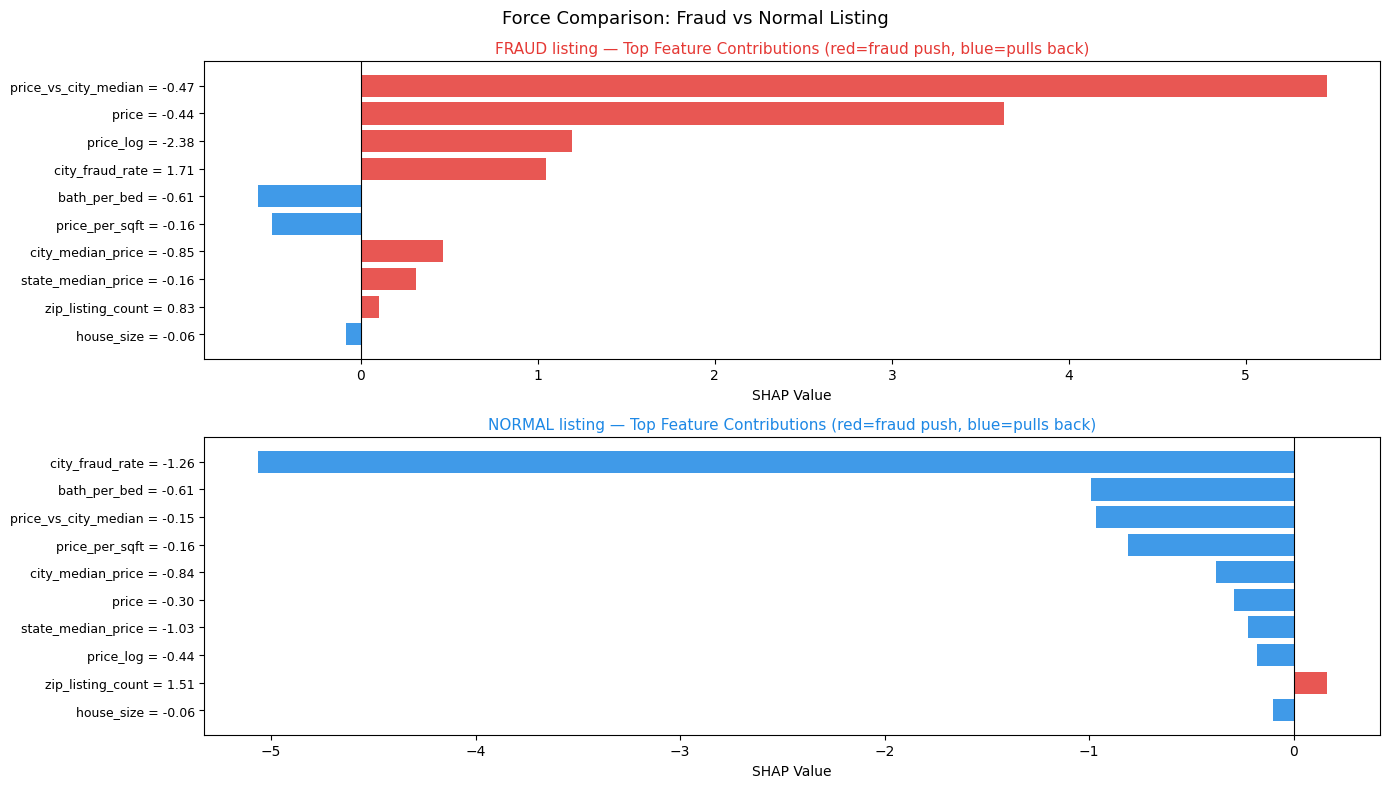

In [13]:
plot_force_comparison(
    model=lgbm_model,
    X_sample=X_sample,
    shap_values=shap_values,
    y_sample=y_sample,
    plots_dir=PLOTS_DIR,
    show=True,
)

## 11. Key Insights — Numbers for Interview

In [14]:
fraud_df  = X_sample[y_sample == 1]
normal_df = X_sample[y_sample == 0]

print('=== KEY SHAP INSIGHTS ===')
print(f'Top 5 fraud-indicating features:')
for _, row in importance_df.head(5).iterrows():
    feat = row['feature']
    if feat in fraud_df.columns:
        f_mean = fraud_df[feat].mean()
        n_mean = normal_df[feat].mean()
        pct_diff = (f_mean - n_mean) / (abs(n_mean) + 1e-9) * 100
        print(f'  {feat:<25}: fraud={f_mean:.2f} | normal={n_mean:.2f} | diff={pct_diff:+.1f}%')

print(f'\nInterview talking points:')
top1 = importance_df.iloc[0]['feature']
print(f'  "#{1} feature is {top1} — highest mean |SHAP| value"')
if 'price_per_sqft' in importance_df['feature'].values:
    rank = importance_df[importance_df['feature']=='price_per_sqft'].iloc[0]['rank']
    shap_mean = importance_df[importance_df['feature']=='price_per_sqft'].iloc[0]['mean_shap']
    f_ppsf = fraud_df['price_per_sqft'].mean() if 'price_per_sqft' in fraud_df.columns else 0
    n_ppsf = normal_df['price_per_sqft'].mean() if 'price_per_sqft' in normal_df.columns else 1
    pct = (f_ppsf - n_ppsf) / (abs(n_ppsf) + 1e-9) * 100
    print(f'  "price_per_sqft is rank #{int(rank)} — fraud listings have {pct:.0f}% different price/sqft vs normal"')

=== KEY SHAP INSIGHTS ===
Top 5 fraud-indicating features:
  price_vs_city_median     : fraud=0.09 | normal=-0.01 | diff=+779.8%
  city_fraud_rate          : fraud=-0.13 | normal=-0.03 | diff=-294.9%
  price_per_sqft           : fraud=0.10 | normal=-0.01 | diff=+1608.2%
  bath_per_bed             : fraud=0.00 | normal=0.00 | diff=-6.4%
  price                    : fraud=0.09 | normal=-0.03 | diff=+414.6%

Interview talking points:
  "#1 feature is price_vs_city_median — highest mean |SHAP| value"
  "price_per_sqft is rank #3 — fraud listings have 1608% different price/sqft vs normal"


## 12. Write business_insights.md

In [15]:
out_path = write_business_insights(
    importance_df=importance_df,
    cfg=cfg,
    shap_values=shap_values,
    X_sample=X_sample,
    y_sample=y_sample,
)
print(f'✅ business_insights.md saved → {out_path}')

2026-05-18 10:17:37,713 - src.shap_analysis - INFO - Business insights saved → reports\business_insights.md


✅ business_insights.md saved → reports\business_insights.md


## 13. Save SHAP Artifacts

In [16]:
# Save shap values + sample for inference pipeline
shap_artifacts = {
    'shap_values':    shap_values,
    'X_sample':       X_sample,
    'y_sample':       y_sample,
    'importance_df':  importance_df,
    'feature_names':  feature_names,
    'top5_features':  importance_df.head(5)['feature'].tolist(),
}
shap_path = Path(cfg['data']['processed_path']) / 'shap_artifacts.pkl'
with open(shap_path, 'wb') as f:
    pickle.dump(shap_artifacts, f)
print(f'✅ SHAP artifacts saved → {shap_path}')

# Save importance CSV
imp_csv = Path(cfg['paths']['reports']) / 'shap_importance.csv'
importance_df.to_csv(imp_csv, index=False)
print(f'✅ Feature importance CSV → {imp_csv}')

✅ SHAP artifacts saved → data\processed\shap_artifacts.pkl
✅ Feature importance CSV → reports\shap_importance.csv


## 14. Day 9 Exit Criteria

In [17]:
expected_plots = [
    'shap_summary_beeswarm.png',
    'shap_bar_importance.png',
    'shap_waterfall_fraud_1.png',
    'shap_waterfall_fraud_2.png',
    'shap_waterfall_fraud_3.png',
    'shap_dependence_price_per_sqft.png',
    'shap_force_comparison.png',
]

print('=== DAY 9 EXIT CRITERIA ===')
checks = [
    ('SHAP values computed',
     shap_values is not None),
    ('LightGBM model saved (lgbm_model.pkl)',
     Path(cfg['paths']['lgbm_model']).exists()),
    ('Top 5 features identified',
     len(importance_df) >= 5),
    ('All 7 SHAP plots saved',
     all((Path(PLOTS_DIR) / p).exists() for p in expected_plots)),
    ('business_insights.md written',
     Path(cfg['paths']['business_insights']).exists()),
    ('SHAP artifacts saved',
     shap_path.exists()),
    ('Feature importance CSV saved',
     imp_csv.exists()),
]

all_pass = True
for label, result in checks:
    icon = '☑' if result else '☒'
    if not result: all_pass = False
    print(f'  {icon} {label}')

print(f'\n{"✅ All passed" if all_pass else "⚠️ Some failed"}')

print(f'\n=== TOP 5 FRAUD SIGNALS ===')
for _, row in importance_df.head(5).iterrows():
    print(f'  #{int(row["rank"])} {row["feature"]:<25} mean|SHAP|={row["mean_shap"]:.4f}')

print(f'\n→ Ready for Day 10 — PostgreSQL + SQLAlchemy')

=== DAY 9 EXIT CRITERIA ===
  ☑ SHAP values computed
  ☑ LightGBM model saved (lgbm_model.pkl)
  ☑ Top 5 features identified
  ☑ All 7 SHAP plots saved
  ☑ business_insights.md written
  ☑ SHAP artifacts saved
  ☑ Feature importance CSV saved

✅ All passed

=== TOP 5 FRAUD SIGNALS ===
  #1 price_vs_city_median      mean|SHAP|=1.3156
  #2 city_fraud_rate           mean|SHAP|=0.6812
  #3 price_per_sqft            mean|SHAP|=0.6623
  #4 bath_per_bed              mean|SHAP|=0.4264
  #5 price                     mean|SHAP|=0.3614

→ Ready for Day 10 — PostgreSQL + SQLAlchemy
